# Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\WELCOME\Desktop\PCOS-Disease-Prediction\processed\pcos_cleaned.csv")

In [3]:
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58
0,1.0,1.0,0.0,28.0,44.6,152.0,19.30,15.0,78.0,22.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,2.0,0.0,36.0,65.0,161.5,24.92,15.0,74.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,3.0,1.0,33.0,68.8,165.0,25.27,11.0,72.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,4.0,0.0,37.0,65.0,148.0,29.67,13.0,72.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,5.0,0.0,25.0,52.0,161.0,20.06,11.0,72.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Handle Missing Values

In [4]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [5]:
df = df.dropna()

In [6]:
df.shape

(538, 44)

## Rename Columns

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df = df.rename(columns={
    "Sl. No": "sr_no",
    "Patient File No.": "patient_id",
    "PCOS (Y/N)": "pcos",
    "Age (yrs)": "age_yrs",
    "Weight (Kg)": "weight_kg",
    "Height(Cm)": "height_cm",
    "BMI": "bmi",
    "Blood Group": "blood_group",
    "Pulse rate(bpm)": "pulse_rate",
    "RR (breaths/min)": "respiratory_rate",
    "Hb(g/dl)": "hb",
    "Cycle(R/I)": "cycle_type",
    "Cycle length(days)": "cycle_length",
    "Marraige Status (Yrs)": "marriage_yrs",
    "Pregnant(Y/N)": "pregnant",
    "No. of abortions": "abortions",
    "I beta-HCG(mIU/mL)": "beta_hcg_1",
    "II beta-HCG(mIU/mL)": "beta_hcg_2",
    "FSH(mIU/mL)": "fsh",
    "LH(mIU/mL)": "lh",
    "FSH/LH": "fsh_lh_ratio",
    "Hip(inch)": "hip_inch",
    "Waist(inch)": "waist_inch",
    "Waist:Hip Ratio": "waist_hip_ratio",
    "TSH (mIU/L)": "tsh",
    "AMH(ng/mL)": "amh",
    "PRL(ng/mL)": "prolactin",
    "Vit D3 (ng/mL)": "vit_d3",
    "PRG(ng/mL)": "progesterone",
    "RBS(mg/dl)": "rbs",
    "Weight gain(Y/N)": "weight_gain",
    "hair growth(Y/N)": "hair_growth",
    "Skin darkening (Y/N)": "skin_darkening",
    "Hair loss(Y/N)": "hair_loss",
    "Pimples(Y/N)": "pimples",
    "Fast food (Y/N)": "fast_food",
    "Reg.Exercise(Y/N)": "exercise",
    "BP _Systolic (mmHg)": "bp_sys",
    "BP _Diastolic (mmHg)": "bp_dia",
    "Follicle No. (L)": "follicle_left",
    "Follicle No. (R)": "follicle_right",
    "Avg. F size (L) (mm)": "follicle_size_left",
    "Avg. F size (R) (mm)": "follicle_size_right",
    "Endometrium (mm)": "endometrium"
})

In [9]:
list(df.columns)

['sr_no',
 'patient_id',
 'pcos',
 'age_yrs',
 'weight_kg',
 'height_cm',
 'bmi',
 'blood_group',
 'pulse_rate',
 'respiratory_rate',
 'hb',
 'cycle_type',
 'cycle_length',
 'marriage_yrs',
 'pregnant',
 'No. of aborptions',
 'I   beta-HCG(mIU/mL)',
 'II    beta-HCG(mIU/mL)',
 'fsh',
 'lh',
 'fsh_lh_ratio',
 'hip_inch',
 'waist_inch',
 'waist_hip_ratio',
 'tsh',
 'amh',
 'prolactin',
 'vit_d3',
 'progesterone',
 'rbs',
 'weight_gain',
 'hair_growth',
 'skin_darkening',
 'hair_loss',
 'pimples',
 'fast_food',
 'exercise',
 'bp_sys',
 'bp_dia',
 'follicle_left',
 'follicle_right',
 'follicle_size_left',
 'follicle_size_right',
 'endometrium']

In [10]:
df = df.rename(columns={
    "No. of abortions": "abortions",
    "I   beta-HCG(mIU/mL)": "beta_hcg_1",
    "II    beta-HCG(mIU/mL)": "beta_hcg_2"
})

In [11]:
df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")
df["beta_hcg_2"] = pd.to_numeric(df["beta_hcg_2"], errors="coerce")
df["amh"] = pd.to_numeric(df["amh"], errors="coerce")

## Missing Values

In [12]:
df.isnull().sum().sort_values(ascending=False)

bmi                    1
beta_hcg_2             1
amh                    1
sr_no                  0
age_yrs                0
weight_kg              0
height_cm              0
blood_group            0
pulse_rate             0
respiratory_rate       0
pcos                   0
patient_id             0
cycle_type             0
hb                     0
pregnant               0
cycle_length           0
No. of aborptions      0
beta_hcg_1             0
fsh                    0
marriage_yrs           0
lh                     0
fsh_lh_ratio           0
waist_inch             0
hip_inch               0
waist_hip_ratio        0
tsh                    0
prolactin              0
vit_d3                 0
progesterone           0
rbs                    0
weight_gain            0
hair_growth            0
skin_darkening         0
hair_loss              0
pimples                0
fast_food              0
exercise               0
bp_sys                 0
bp_dia                 0
follicle_left          0


In [13]:
df.duplicated().sum()

np.int64(0)

## PCOS Distribution

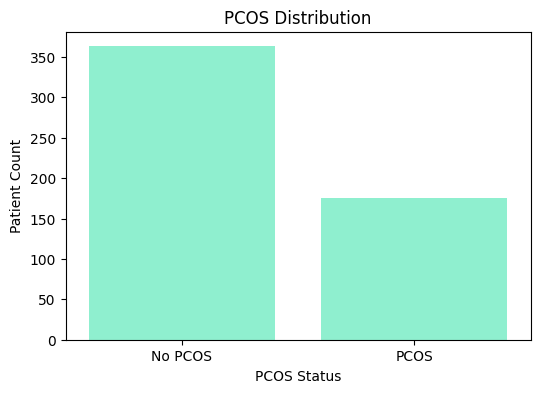

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="pcos",
    data=df,
    color="aquamarine"
)

plt.title("PCOS Distribution")
plt.xlabel("PCOS Status")
plt.ylabel("Patient Count")

plt.xticks([0,1], ["No PCOS", "PCOS"])

plt.show()

## Age Distribution

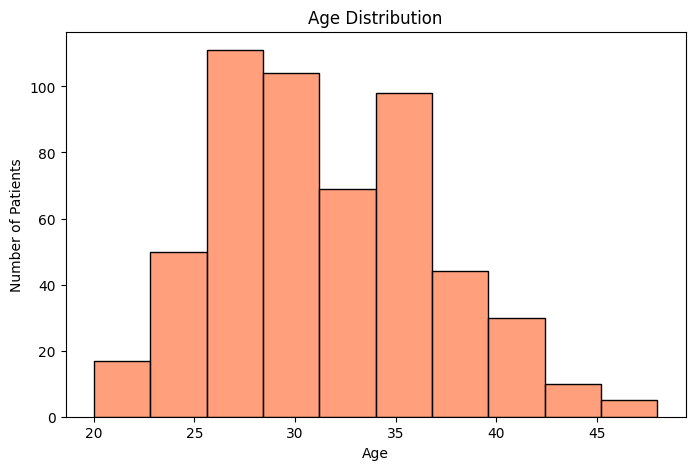

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age_yrs"],
    color="coral",
    bins=10
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

## BMI Distribution

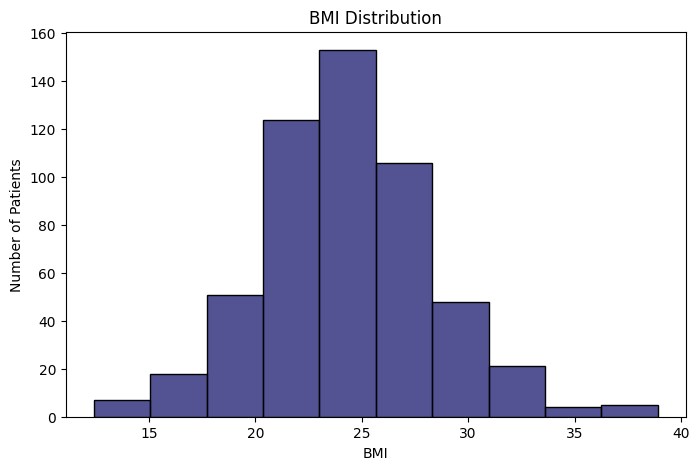

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["bmi"],
    color="midnightblue",
    bins=10
)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")

plt.show()

## Weight Distribution

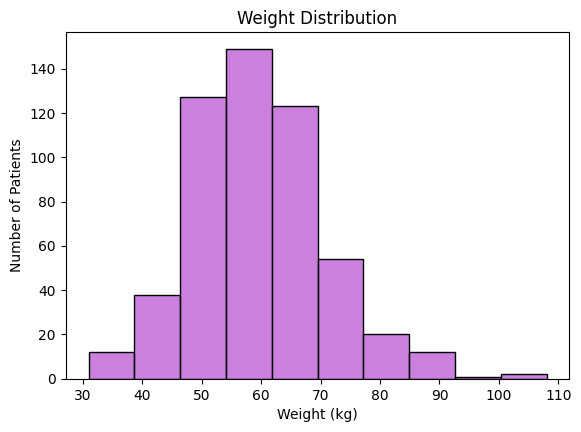

In [17]:
plt.figure(figsize=(6.5,4.5))

sns.histplot(
    df["weight_kg"],
    bins=10,
    color="mediumorchid"
)

plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of Patients")

plt.show()

## PCOS vs BMI

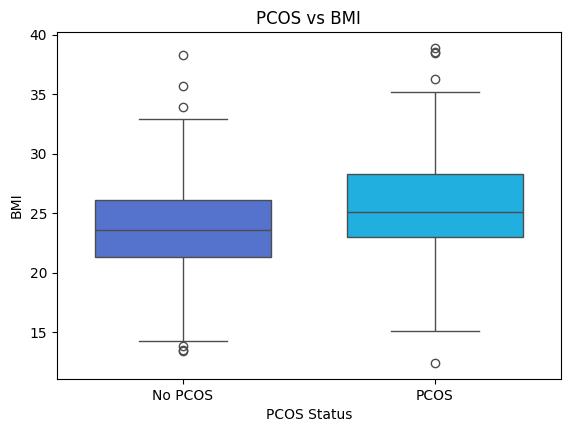

In [18]:
plt.figure(figsize=(6.5,4.5))

sns.boxplot(
    x="pcos",
    y="bmi",
    hue="pcos",
    data=df,
    palette=["royalblue", "deepskyblue"],
    width=0.7,
    legend=False
)

plt.title("PCOS vs BMI")
plt.xlabel("PCOS Status")
plt.ylabel("BMI")

plt.xticks([0,1], ["No PCOS", "PCOS"])

plt.show()

### Observation
Patients with PCOS tend to show slightly higher BMI values compared to non-PCOS patients.

## Waist-Hip Ratio vs PCOS

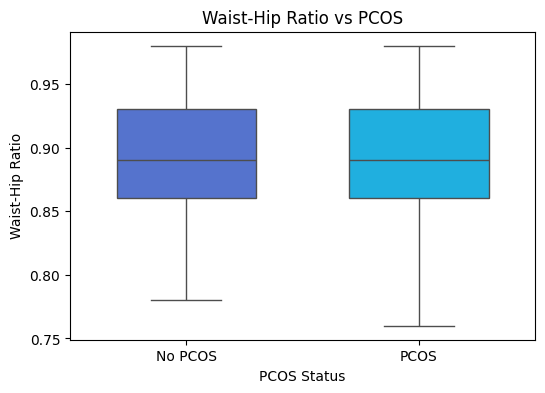

In [19]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="pcos",
    y="waist_hip_ratio",
    hue="pcos",
    data=df,
    palette=["royalblue", "deepskyblue"],
    width=0.6,
    legend=False
)

plt.title("Waist-Hip Ratio vs PCOS")
plt.xlabel("PCOS Status")
plt.ylabel("Waist-Hip Ratio")

plt.xticks([0,1], ["No PCOS", "PCOS"])

plt.show()

### Observation
The waist-hip ratios of PCOS and non-PCOS patients appear relatively similar, indicating no major visible difference in body fat distribution within this dataset.

## Cycle Length vs PCOS

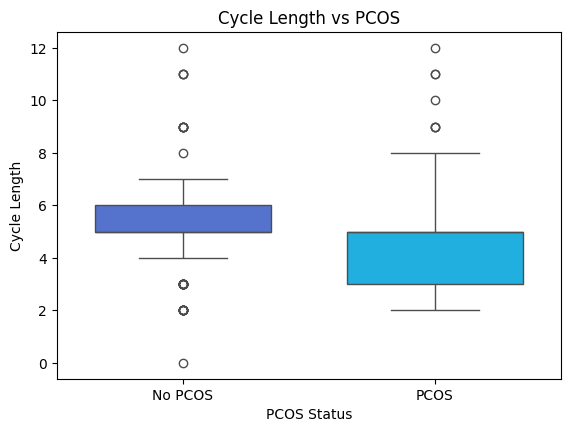

In [20]:
plt.figure(figsize=(6.5,4.5))

sns.boxplot(
    x="pcos",
    y="cycle_length",
    hue="pcos",
    data=df,
    palette=["royalblue", "deepskyblue"],
    width=0.7,
    legend=False
)

plt.title("Cycle Length vs PCOS")
plt.xlabel("PCOS Status")
plt.ylabel("Cycle Length")

plt.xticks([0,1], ["No PCOS", "PCOS"])

plt.show()

### Observation
PCOS patients tend to show greater variation in menstrual cycle length compared to non-PCOS patients.

## AMH Levels vs PCOS

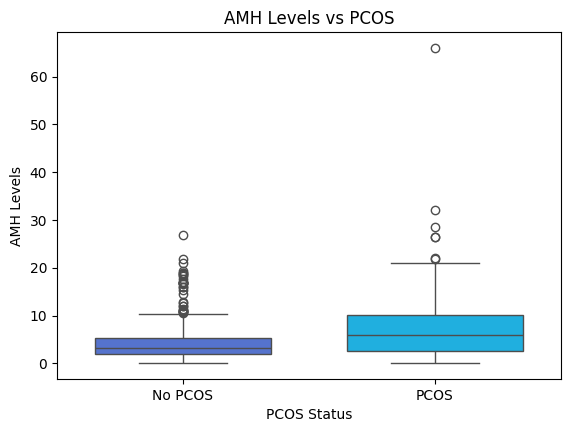

In [21]:
plt.figure(figsize=(6.5,4.5))

sns.boxplot(
    x="pcos",
    y="amh",
    hue="pcos",
    data=df,
    palette=["royalblue", "deepskyblue"],
    width=0.7,
    legend=False
)

plt.title("AMH Levels vs PCOS")
plt.xlabel("PCOS Status")
plt.ylabel("AMH Levels")

plt.xticks([0,1], ["No PCOS", "PCOS"])

plt.show()

### Observation
PCOS patients tend to show higher AMH levels compared to non-PCOS patients. The graph also shows greater variation and more outliers among PCOS patients, indicating hormonal imbalance associated with PCOS.

## Weight Gain vs PCOS

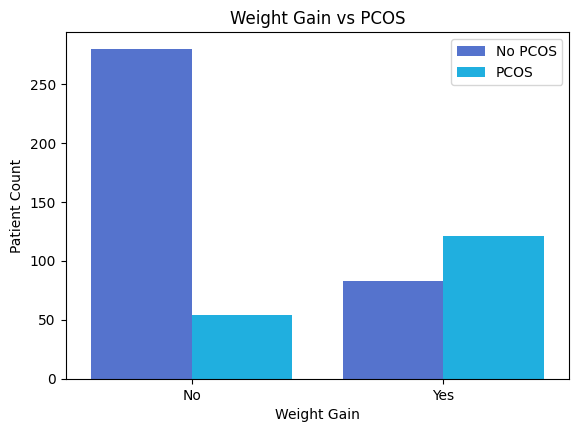

In [22]:
plt.figure(figsize=(6.5,4.5))

sns.countplot(
    x="weight_gain",
    hue="pcos",
    data=df,
    palette=["royalblue", "deepskyblue"]
)

plt.title("Weight Gain vs PCOS")
plt.xlabel("Weight Gain")
plt.ylabel("Patient Count")

plt.xticks([0,1], ["No", "Yes"])

plt.legend(["No PCOS", "PCOS"])

plt.show()

### Observation
Patients with PCOS show a higher frequency of weight gain compared to non-PCOS patients, indicating a possible relationship between PCOS and metabolic or lifestyle-related changes.

## Correlation Heatmap

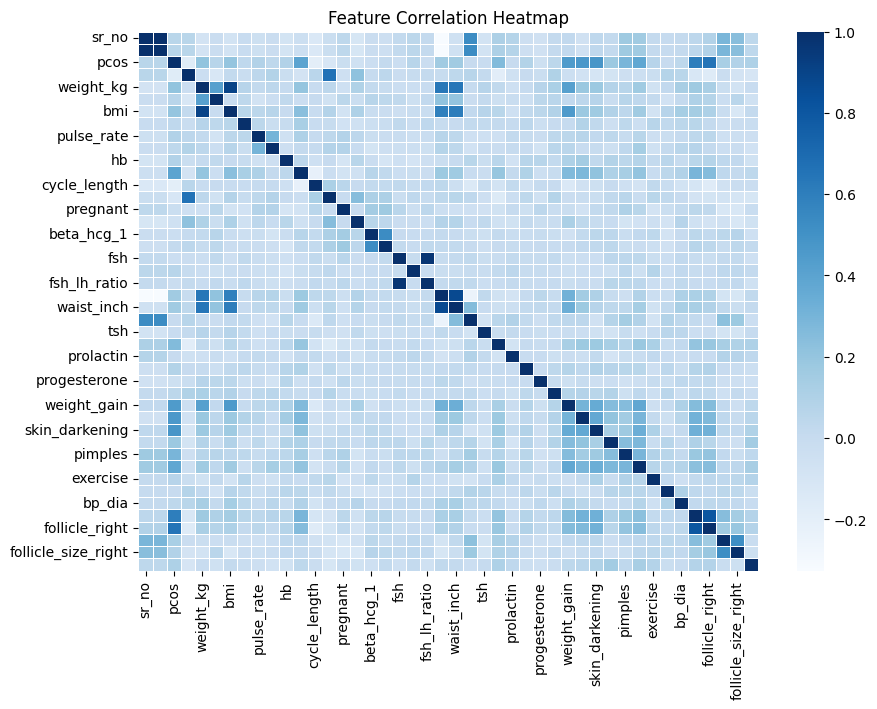

In [23]:
plt.figure(figsize=(10,7))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    cmap="Blues",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.show()

### Observation
The heatmap highlights relationships between clinical, hormonal, and lifestyle-related features. Body measurements and follicle-related variables show noticeable positive correlations, while several features display weaker relationships, indicating diverse clinical patterns within the PCOS dataset.